# STAC connect to ClimateDT weather stations

In [1]:
from odc import stac as odc_stac
from pystac_client import Client
import xarray as xr
import xarray as xr
import numpy as np 

### Connect to the eodc stac with pystac CLient

In [7]:
eodc_catalog = Client.open(
    "https://stac.eodc.eu/api/v1",
)

collection = "climatedt"

In [8]:
search = eodc_catalog.search(collections=[collection])
for item in search.items():
    print(item.id)

IFS-FESOM-story-nudging-Tplus2
IFS-FESOM-story-nudging-hist
IFS-FESOM-story-nudging-cont
IFS-NEMO-ScenarioMIP
IFS-NEMO-HighResMIP
IFS-NEMO-CMIP6


Search for desired model

In [9]:
item = next(
    eodc_catalog.search(collections=[collection], ids=["IFS-FESOM-story-nudging-Tplus2"]).items()
)
item

<Item id=IFS-FESOM-story-nudging-Tplus2>

In [10]:
asset = item.assets["data"]
store_url = asset.href
print("href:", store_url)

href: https://objects.eodc.eu/68e13833a1624f43ba2cac01376a18af:destine-climate-dt/climate-dt.zarr


### Open data with xarray

In [11]:
coords = xr.open_zarr(
    store_url,
    **asset.extra_fields["xarray:open_zarr_kwargs"]
)

print(coords)

<xarray.Dataset> Size: 4GB
Dimensions:    (datetimes: 438288, points: 629)
Coordinates:
  * datetimes  (datetimes) datetime64[ns] 4MB 1990-01-01 ... 2039-12-31T23:00:00
  * points     (points) int64 5kB 0 1 2 3 4 5 6 ... 622 623 624 625 626 627 628
    latitude   (points) float64 5kB dask.array<chunksize=(629,), meta=np.ndarray>
    longitude  (points) float64 5kB dask.array<chunksize=(629,), meta=np.ndarray>
Data variables:
    2t         (datetimes, points) float64 2GB dask.array<chunksize=(438288, 100), meta=np.ndarray>
    tp         (datetimes, points) float64 2GB dask.array<chunksize=(438288, 100), meta=np.ndarray>


Plot single point


For TU user: Point id is the same as in the climate stations csv

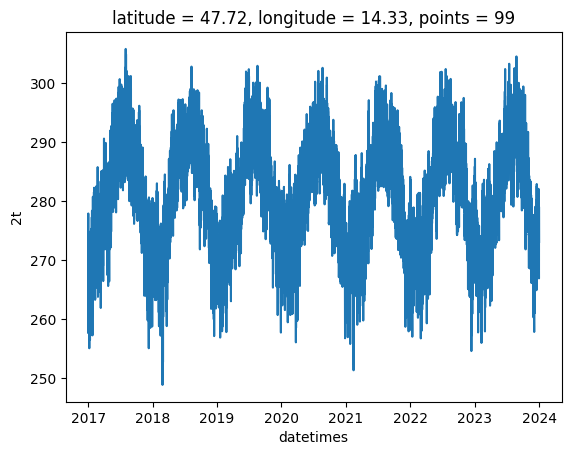

In [66]:
coords["2t"].isel(points=99).plot()

### Create subset with bbox and year

In [12]:
# Bounding box
lon_min, lat_min, lon_max, lat_max = 15.839539,47.565407,16.877747,48.039529
# Compute lat/lon (small, so this is fast)
lats = coords.latitude.compute()
lons = coords.longitude.compute()

# Boolean mask for points within the bbox
mask = (
    (lats >= lat_min) & (lats <= lat_max) &
    (lons >= lon_min) & (lons <= lon_max)
)

# Subset
ds_subset = coords.sel(points=mask.values)

ds_2023 = ds_subset.sel(datetimes=ds_subset.datetimes.dt.year == 2023).compute()
print(ds_2023)

<xarray.Dataset> Size: 5MB
Dimensions:    (datetimes: 8760, points: 34)
Coordinates:
  * datetimes  (datetimes) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:0...
  * points     (points) int64 272B 0 5 22 31 33 60 ... 332 377 378 381 382 383
    latitude   (points) float64 272B 48.01 48.01 47.85 ... 47.6 47.58 47.74
    longitude  (points) float64 272B 16.84 16.24 16.54 ... 16.29 16.1 16.39
Data variables:
    2t         (datetimes, points) float64 2MB 279.0 276.1 276.1 ... 274.2 273.0
    tp         (datetimes, points) float64 2MB 0.0 0.0 0.0 ... 0.0 2.936e-06 0.0


### Plot both values over 2023

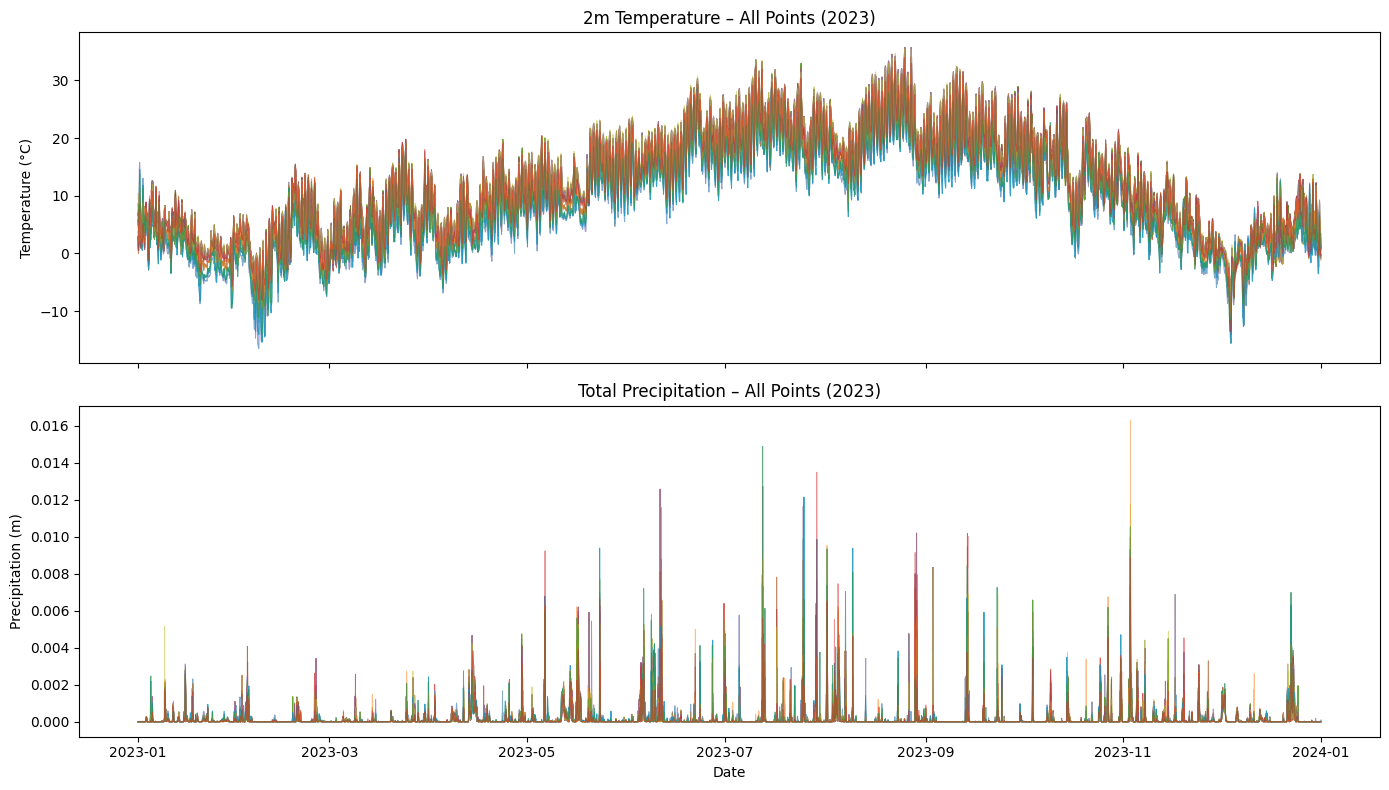

In [14]:
import matplotlib.pyplot as plt

# Select 2024 and compute

# --- Plot 2t (2m Temperature) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for point in ds_2023.points.values:
    axes[0].plot(
        ds_2023.datetimes,
        ds_2023["2t"].sel(points=point) - 273.15,  # K to °C
        alpha=0.5, linewidth=0.7
    )
axes[0].set_title("2m Temperature – All Points (2023)")
axes[0].set_ylabel("Temperature (°C)")

# --- Plot tp (Total Precipitation) ---
for point in ds_2023.points.values:
    axes[1].plot(
        ds_2023.datetimes,
        ds_2023["tp"].sel(points=point),
        alpha=0.5, linewidth=0.7
    )
axes[1].set_title("Total Precipitation – All Points (2023)")
axes[1].set_ylabel("Precipitation (m)")

plt.xlabel("Date")
plt.tight_layout()
plt.show()